In [15]:
#Starter-script for Prophet-konkurranse
#--------------------------------------
#
#- Leser train.csv
#- Leser test_features.csv
#- Trener Prophet-modell
#- Lager submission.csv

#Du kan forbedre:
#- features
#- skalering
#- lag-features
#- hyperparametre
#- log-transform
#- osv.

In [16]:
import pandas as pd
from prophet import Prophet


In [17]:
lagnsavn = "phase06_feels_like"

# Sett False for å hoppe over tregere sammenligning (baseline / weather / holidays)
RUN_COMPARISON = True

In [18]:
# --------------------------------------------------
# 1. LES DATA  (lokale filer – ingen nettverkskall)
# --------------------------------------------------
LOCAL_TRAIN = "bysykkel_train.csv"
LOCAL_TEST  = "test_compete.csv"

print("Leser data ...")
train = pd.read_csv(LOCAL_TRAIN, parse_dates=["ds"])
test  = pd.read_csv(LOCAL_TEST,  parse_dates=["ds"])
train = train.sort_values("ds")
test  = test.sort_values("ds")
print("done!")


Leser data ...
done!


In [19]:
weather_cols = [
    "air_temperature",
    "wind_speed",
    "precipitation_amount"
]

train[weather_cols] = train[weather_cols].ffill().bfill()
test[weather_cols] = test[weather_cols].ffill().bfill()

In [20]:
# --------------------------------------------------
# 2. ADD HOLIDAYS  (cached to holidays_cache.json)
# --------------------------------------------------
import requests, json, os

HOLIDAYS_CACHE = "holidays_cache.json"

def get_norwegian_holidays(years):
    """Fetch Norwegian public holidays from Nager.at API, with local cache."""
    if os.path.exists(HOLIDAYS_CACHE):
        with open(HOLIDAYS_CACHE) as f:
            cache = json.load(f)
    else:
        cache = {}

    all_holidays = []
    changed = False
    for year in years:
        key = str(year)
        if key not in cache:
            url = f"https://date.nager.at/api/v3/publicholidays/{year}/NO"
            resp = requests.get(url, timeout=10)
            resp.raise_for_status()
            dates = [h["date"] for h in resp.json()]
            cache[key] = dates
            changed = True
            print(f"  Fetched holidays for {year} from API")
        else:
            print(f"  Loaded holidays for {year} from cache")
        all_holidays.extend(cache[key])

    if changed:
        with open(HOLIDAYS_CACHE, "w") as f:
            json.dump(cache, f)

    return set(all_holidays)

# Fetch holidays for all years in the data
train_years = range(train["ds"].dt.year.min(), train["ds"].dt.year.max() + 1)
test_years  = range(test["ds"].dt.year.min(),  test["ds"].dt.year.max()  + 1)
all_years   = sorted(set(train_years) | set(test_years))

holiday_dates = get_norwegian_holidays(all_years)

train["is_holiday"] = train["ds"].dt.strftime("%Y-%m-%d").isin(holiday_dates).astype(int)
test["is_holiday"]  = test["ds"].dt.strftime("%Y-%m-%d").isin(holiday_dates).astype(int)

print(f"Found {len(holiday_dates)} unique holiday dates across {len(all_years)} years")
print(f"Holiday rows in train: {train['is_holiday'].sum()}")
print(f"Holiday rows in test:  {test['is_holiday'].sum()}")


  Loaded holidays for 2018 from cache
  Loaded holidays for 2019 from cache
  Loaded holidays for 2020 from cache
  Loaded holidays for 2021 from cache
  Loaded holidays for 2022 from cache
  Loaded holidays for 2023 from cache
  Loaded holidays for 2024 from cache
  Loaded holidays for 2025 from cache
Found 96 unique holiday dates across 8 years
Holiday rows in train: 323
Holiday rows in test:  31


In [21]:
# --------------------------------------------------
# 3. ADD DAYLIGHT HOURS
# --------------------------------------------------
from astral import LocationInfo
from astral.sun import sun
import datetime

city = LocationInfo("Trondheim", "Norway", "Europe/Oslo", 63.43, 10.40)

def get_daylight_hours(date):
    """Calculate daylight hours for a given date in Trondheim."""
    try:
        s = sun(city.observer, date=date)
        return (s["sunset"] - s["sunrise"]).total_seconds() / 3600
    except Exception:
        # Handle polar day/night edge cases
        month = date.month
        if month in [6, 7]:
            return 22.0  # Near-midnight sun
        elif month in [12, 1]:
            return 4.5   # Very short days
        return 12.0

# Compute for unique dates only (faster)
all_dates = pd.concat([train["ds"], test["ds"]]).dt.date.unique()
daylight_map = {d: get_daylight_hours(d) for d in all_dates}

train["daylight_hours"] = train["ds"].dt.date.map(daylight_map)
test["daylight_hours"] = test["ds"].dt.date.map(daylight_map)

print(f"Daylight range: {train['daylight_hours'].min():.1f}h – {train['daylight_hours'].max():.1f}h")

Daylight range: 4.5h – 22.0h


In [22]:
# --------------------------------------------------
# FEATURE ENGINEERING
# --------------------------------------------------
import numpy as np

def add_features(df):
    """Add engineered features to a DataFrame."""

    # --- Time-of-day features ---
    df["is_morning_rush"] = ((df["hour"] >= 6) & (df["hour"] <= 9)).astype(int)
    df["is_evening_rush"] = ((df["hour"] >= 15) & (df["hour"] <= 18)).astype(int)
    df["is_rush_hour"] = (df["is_morning_rush"] | df["is_evening_rush"]).astype(int)
    df["is_night"] = ((df["hour"] >= 0) & (df["hour"] < 6)).astype(int)

    # --- Weather interaction features ---
    # Rain + cold = very few cyclists
    df["cold_rain"] = (
        (df["air_temperature"] < 5) &
        (df["precipitation_amount"] > 0)
    ).astype(int)

    # Nice cycling weather
    df["nice_weather"] = (
        (df["air_temperature"].between(15, 25)) &
        (df["precipitation_amount"] == 0) &
        (df["wind_speed"] < 5)
    ).astype(int)

    # Temperature squared (captures non-linear effect: too cold AND too hot are bad)
    df["temp_squared"] = df["air_temperature"] ** 2

    # --- Cyclical encoding ---
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["weekday_sin"] = np.sin(2 * np.pi * df["weekday"] / 7)
    df["weekday_cos"] = np.cos(2 * np.pi * df["weekday"] / 7)

    return df

train = add_features(train)
test = add_features(test)

print("New features added:")
new_cols = [
    "is_morning_rush", "is_evening_rush", "is_rush_hour", "is_night",
    "cold_rain", "nice_weather", "temp_squared",
    "hour_sin", "hour_cos", "month_sin", "month_cos", "weekday_sin", "weekday_cos"
]
for c in new_cols:
    print(f"  {c}: train range [{train[c].min():.2f}, {train[c].max():.2f}]")

New features added:
  is_morning_rush: train range [0.00, 1.00]
  is_evening_rush: train range [0.00, 1.00]
  is_rush_hour: train range [0.00, 1.00]
  is_night: train range [0.00, 1.00]
  cold_rain: train range [0.00, 1.00]
  nice_weather: train range [0.00, 1.00]
  temp_squared: train range [0.00, 981.78]
  hour_sin: train range [-1.00, 1.00]
  hour_cos: train range [-1.00, 1.00]
  month_sin: train range [-1.00, 1.00]
  month_cos: train range [-1.00, 1.00]
  weekday_sin: train range [-0.97, 0.97]
  weekday_cos: train range [-0.90, 1.00]


In [23]:
# --------------------------------------------------
# FEELS-LIKE TEMPERATURE
# --------------------------------------------------
import numpy as np

def compute_feels_like(temp, wind_speed):
    """
    Wind chill formula (Environment Canada) for temp < 10°C.
    For temp >= 10°C, returns the raw temperature.
    Wind speed should be in m/s; formula expects km/h.
    """
    wind_kmh = wind_speed * 3.6  # Convert m/s to km/h
    wind_chill = (
        13.12
        + 0.6215 * temp
        - 11.37 * np.power(np.maximum(wind_kmh, 1), 0.16)
        + 0.3965 * temp * np.power(np.maximum(wind_kmh, 1), 0.16)
    )
    return np.where(temp < 10, wind_chill, temp)

train["feels_like"] = compute_feels_like(
    train["air_temperature"].values,
    train["wind_speed"].values
)
test["feels_like"] = compute_feels_like(
    test["air_temperature"].values,
    test["wind_speed"].values
)

print(f"Feels-like range: {train['feels_like'].min():.1f} – {train['feels_like'].max():.1f}")
print(f"Actual temp range: {train['air_temperature'].min():.1f} – {train['air_temperature'].max():.1f}")

Feels-like range: -26.1 – 31.3
Actual temp range: -14.4 – 31.3


In [24]:
regressors = [
    "is_weekend",
    "feels_like",          # Phase 6: Replaces air_temperature
    "wind_speed",
    "precipitation_amount",
    "is_holiday",
    "daylight_hours",
    # Phase 5: Feature engineering
    "is_rush_hour",
    "is_night",
    "cold_rain",
    "nice_weather",
    "temp_squared",
    "hour_sin",
    "hour_cos",
]

In [25]:
# --------------------------------------------------
# LOG-TRANSFORM TARGET
# --------------------------------------------------
import numpy as np

train["y_original"] = train["y"].copy()
train["y"] = np.log1p(train["y"])  # log(1 + y) to handle y=0

print(f"Original y range: {train['y_original'].min():.0f} – {train['y_original'].max():.0f}")
print(f"Log y range: {train['y'].min():.2f} – {train['y'].max():.2f}")

Original y range: 1 – 910
Log y range: 0.69 – 6.81


In [26]:
# --------------------------------------------------
# 4. DEFINER PROPHET
# --------------------------------------------------

m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    seasonality_mode="additive"  # additive works better with log-transformed data
)

for r in regressors:
    m.add_regressor(r)

In [27]:
print("Trener modell ...")
m.fit(train[["ds", "y"] + regressors])

Trener modell ...


08:59:12 - cmdstanpy - INFO - Chain [1] start processing
08:59:25 - cmdstanpy - INFO - Chain [1] done processing


In [28]:
# --------------------------------------------------
# 6. PREDIKSJON PÅ TEST
# --------------------------------------------------
future = test[["ds"] + regressors].copy()
forecast = m.predict(future)

In [29]:
submission = pd.DataFrame({
    "ds": test["ds"],
    "yhat": forecast["yhat"]
})

# Inverse log-transform
submission["yhat"] = np.expm1(submission["yhat"])  # exp(yhat) - 1

# Clip negative predictions
submission["yhat"] = submission["yhat"].clip(lower=0)

In [30]:
#lagre innlevering
submission.to_csv(f"submission_{lagnsavn}.csv", index=False, sep=',')
print("✅ Ferdig!")
print("Submission lagret")

✅ Ferdig!
Submission lagret


Training:   2018-05-15 09:00:00 → 2025-03-31 21:00:00  (11326 rows)
Validation: 2025-04-01 03:00:00 → 2025-04-30 21:00:00  (210 rows)



08:59:26 - cmdstanpy - INFO - Chain [1] start processing
08:59:35 - cmdstanpy - INFO - Chain [1] done processing
08:59:36 - cmdstanpy - INFO - Chain [1] start processing
08:59:47 - cmdstanpy - INFO - Chain [1] done processing
08:59:47 - cmdstanpy - INFO - Chain [1] start processing
08:59:56 - cmdstanpy - INFO - Chain [1] done processing
08:59:56 - cmdstanpy - INFO - Chain [1] start processing
09:00:09 - cmdstanpy - INFO - Chain [1] done processing
09:00:10 - cmdstanpy - INFO - Chain [1] start processing
09:00:23 - cmdstanpy - INFO - Chain [1] done processing


Baseline RMSE (is_weekend only):            61.89
Weather  RMSE (+ weather cols):             57.53
Holiday  RMSE (+ weather + holidays):       53.57
Daylight RMSE (+ weather + hol + daylight): 53.03
Features RMSE (+ feature engineering):      54.38
Feels Like RMSE (feels_like replaces temp): 42.30

Weather improvement over baseline:          4.36  (7.0%)
Holiday improvement over weather:           3.96  (6.9%)
Daylight improvement over holidays:         0.54  (1.0%)
Features improvement over daylight:         -1.35  (-2.5%)
Feels Like improvement over features:       12.07  (22.2%)
Total improvement over baseline:            19.59  (31.7%)


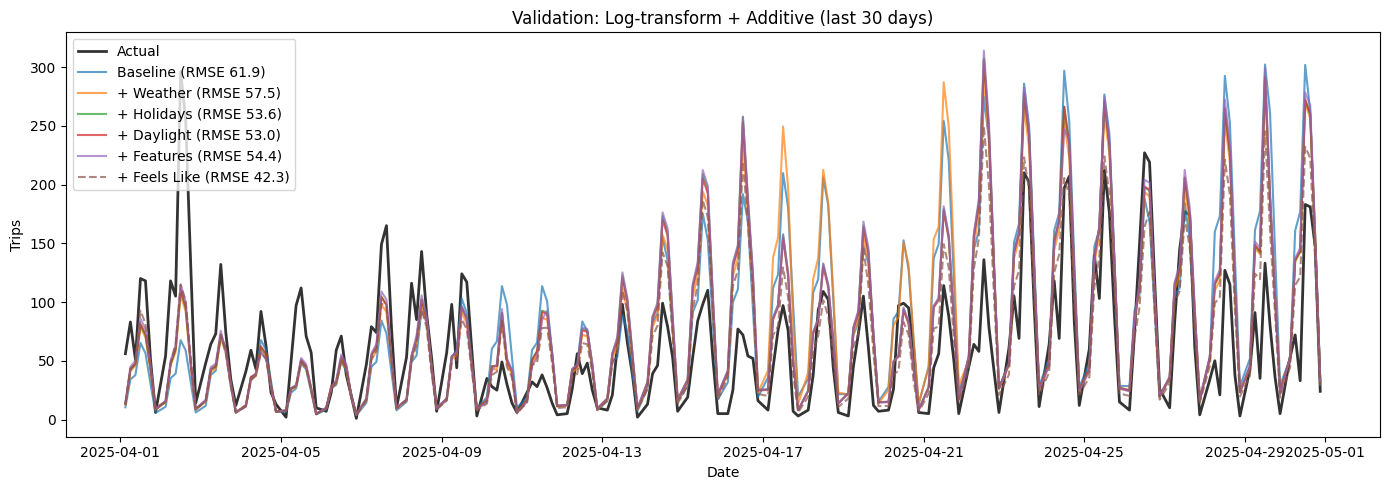

In [31]:
# --------------------------------------------------
# Compare baseline vs weather vs weather+holidays vs +daylight vs +features vs +feels_like on training data
# (all models use log-transform + additive seasonality)
# --------------------------------------------------
if not RUN_COMPARISON:
    print("⏭  Hopper over sammenligning (RUN_COMPARISON=False)")
    raise SystemExit()

from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt

cutoff = train["ds"].max() - pd.Timedelta(days=30)
tr = train[train["ds"] <= cutoff].copy()
val = train[train["ds"] > cutoff].copy()

# val["y"] is already log-transformed; get original for RMSE
val_y_orig = np.expm1(val["y"])

print(f"Training:   {tr['ds'].min()} → {tr['ds'].max()}  ({len(tr)} rows)")
print(f"Validation: {val['ds'].min()} → {val['ds'].max()}  ({len(val)} rows)")
print()

# --- Baseline model (is_weekend only) ---
m_base = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    seasonality_mode="additive"
)
m_base.add_regressor("is_weekend")
m_base.fit(tr[["ds", "y", "is_weekend"]])
fc_base = m_base.predict(val[["ds", "is_weekend"]])
yhat_base = np.expm1(fc_base["yhat"]).clip(lower=0)
rmse_base = root_mean_squared_error(val_y_orig, yhat_base)

# --- Weather model (is_weekend + weather) ---
weather_regs = ["is_weekend", "air_temperature", "wind_speed", "precipitation_amount"]
m_weather = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    seasonality_mode="additive"
)
for r in weather_regs:
    m_weather.add_regressor(r)
m_weather.fit(tr[["ds", "y"] + weather_regs])
fc_weather = m_weather.predict(val[["ds"] + weather_regs])
yhat_weather = np.expm1(fc_weather["yhat"]).clip(lower=0)
rmse_weather = root_mean_squared_error(val_y_orig, yhat_weather)

# --- Weather + Holidays model ---
holiday_regs = ["is_weekend", "air_temperature", "wind_speed", "precipitation_amount", "is_holiday"]
m_holidays = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    seasonality_mode="additive"
)
for r in holiday_regs:
    m_holidays.add_regressor(r)
m_holidays.fit(tr[["ds", "y"] + holiday_regs])
fc_holidays = m_holidays.predict(val[["ds"] + holiday_regs])
yhat_holidays = np.expm1(fc_holidays["yhat"]).clip(lower=0)
rmse_holidays = root_mean_squared_error(val_y_orig, yhat_holidays)

# --- Weather + Holidays + Daylight model ---
daylight_regs = ["is_weekend", "air_temperature", "wind_speed", "precipitation_amount", "is_holiday", "daylight_hours"]
m_daylight = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    seasonality_mode="additive"
)
for r in daylight_regs:
    m_daylight.add_regressor(r)
m_daylight.fit(tr[["ds", "y"] + daylight_regs])
fc_daylight = m_daylight.predict(val[["ds"] + daylight_regs])
yhat_daylight = np.expm1(fc_daylight["yhat"]).clip(lower=0)
rmse_daylight = root_mean_squared_error(val_y_orig, yhat_daylight)

# --- Features model (daylight + feature engineering, still using air_temperature) ---
features_regs = [
    "is_weekend", "air_temperature", "wind_speed", "precipitation_amount",
    "is_holiday", "daylight_hours",
    "is_rush_hour", "is_night", "cold_rain", "nice_weather", "temp_squared",
    "hour_sin", "hour_cos",
]
m_features = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    seasonality_mode="additive"
)
for r in features_regs:
    m_features.add_regressor(r)
m_features.fit(tr[["ds", "y"] + features_regs])
fc_features = m_features.predict(val[["ds"] + features_regs])
yhat_features = np.expm1(fc_features["yhat"]).clip(lower=0)
rmse_features = root_mean_squared_error(val_y_orig, yhat_features)

# --- Feels Like model (features + feels_like replacing air_temperature) ---
fc_feels = m.predict(val[["ds"] + regressors])
yhat_feels = np.expm1(fc_feels["yhat"]).clip(lower=0)
rmse_feels = root_mean_squared_error(val_y_orig, yhat_feels)

print(f"Baseline RMSE (is_weekend only):            {rmse_base:.2f}")
print(f"Weather  RMSE (+ weather cols):             {rmse_weather:.2f}")
print(f"Holiday  RMSE (+ weather + holidays):       {rmse_holidays:.2f}")
print(f"Daylight RMSE (+ weather + hol + daylight): {rmse_daylight:.2f}")
print(f"Features RMSE (+ feature engineering):      {rmse_features:.2f}")
print(f"Feels Like RMSE (feels_like replaces temp): {rmse_feels:.2f}")
print()
print(f"Weather improvement over baseline:          {rmse_base - rmse_weather:.2f}  ({(rmse_base - rmse_weather) / rmse_base * 100:.1f}%)")
print(f"Holiday improvement over weather:           {rmse_weather - rmse_holidays:.2f}  ({(rmse_weather - rmse_holidays) / rmse_weather * 100:.1f}%)")
print(f"Daylight improvement over holidays:         {rmse_holidays - rmse_daylight:.2f}  ({(rmse_holidays - rmse_daylight) / rmse_holidays * 100:.1f}%)")
print(f"Features improvement over daylight:         {rmse_daylight - rmse_features:.2f}  ({(rmse_daylight - rmse_features) / rmse_daylight * 100:.1f}%)")
print(f"Feels Like improvement over features:       {rmse_features - rmse_feels:.2f}  ({(rmse_features - rmse_feels) / rmse_features * 100:.1f}%)")
print(f"Total improvement over baseline:            {rmse_base - rmse_feels:.2f}  ({(rmse_base - rmse_feels) / rmse_base * 100:.1f}%)")

# --- Plot ---
plt.figure(figsize=(14, 5))
plt.plot(val["ds"], val_y_orig, label="Actual", linewidth=2, color="black", alpha=0.8)
plt.plot(val["ds"], yhat_base, label=f"Baseline (RMSE {rmse_base:.1f})", alpha=0.7)
plt.plot(val["ds"], yhat_weather, label=f"+ Weather (RMSE {rmse_weather:.1f})", alpha=0.7)
plt.plot(val["ds"], yhat_holidays, label=f"+ Holidays (RMSE {rmse_holidays:.1f})", alpha=0.7)
plt.plot(val["ds"], yhat_daylight, label=f"+ Daylight (RMSE {rmse_daylight:.1f})", alpha=0.7)
plt.plot(val["ds"], yhat_features, label=f"+ Features (RMSE {rmse_features:.1f})", alpha=0.7)
plt.plot(val["ds"], yhat_feels, label=f"+ Feels Like (RMSE {rmse_feels:.1f})", alpha=0.7, linestyle="--")
plt.title("Validation: Log-transform + Additive (last 30 days)")
plt.xlabel("Date")
plt.ylabel("Trips")
plt.legend()
plt.tight_layout()
plt.show()